# Computing general observables
---

<font size="5"><b>Goal:</b>
Become acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you will learn
---

<font size="4">

1. What an "estimator" is and how to set one up in the json input file
2. What a mixed estimator is and when to use one to compute an observable
3. What a back-propagated estimator is and when to use one to compute an observable
4. How to compute observables in post-processing with afqmctools
</font>

&nbsp;

## Introduction
---

<font size="4">
SAFIRE uses "estimators" to compute observables.
Each estimator corresponds to a formal method for computing an observable - i.e. mixed estimators, back-propagated estimators, etc. - We will explain each of the these in the next section.
As we mentioned in the
</font>

[<font size="4">understanding the Input file tutorial</font>](../02_understanding_the_input_file/02_understanding_the_input_file.html),

<font size="4">
you can add estimators to an AFQMC calculation using an "estimator" input block.
By default, an "energy" estimator is included which is a specialized mixed estimator.
Other estimators allow you to specify one or more additional observables to compute.
</font>

&nbsp;

## Formal Background
---

Although we have not seen this explicitly, we have, so far, computed the ground state energy with AFQMC using a so-called
mixed estimator of the form

$$
\langle \hat{O} \rangle_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle}
$$

where $n$ is the projection step index,
$| \Phi_{n,k} \rangle$ are Slater determinant random walkers with weight $W_{n,k}$ (from importance sampling),
and $| \Psi_T \rangle$ is the trial wavefunction.
The mixed estimator provides an unbiased estimate for any observable which commutes with the Hamiltonian.
For the AFQMC energy, $\hat{O} = \hat{H}$, and trivially $[ \hat{O}, \hat{H} ] = 0$;
therefore, the mixed estimator is an unbiased choice for the total ground state energy.

On the other hand, it is often interesting to compute observables which do not commute with the Hamiltonian.
For example, the one-body reduced density matrix, from which many properties can be computed, does not commute
with the Hamiltonian.
In these cases, a back-propagated estimator is necessary to mitigate the bias that would be incurred
by using a mixed-estimator.
The back-propagated estimator has the form,
$$
\langle \hat{O} \rangle_{BP} = \frac{1}{\sum_k W_{n+m,k}} \sum_k W_{n+m,k} \frac{\langle \tilde{\Phi}_{m,k} | \hat{O} | \Phi_{n,k} \rangle }{\langle \tilde{\Phi}_{m,k} |\Phi_{n,k}\rangle}
$$

where $| \Phi_{n,k} \rangle$ are the usual forward-projected Slater determinant random walkers,
and $| \tilde{\Phi}_{m,k} \rangle$ are the back-propgated walkers given by,
$$
| \tilde{\Phi}_{m,k} \rangle = \hat{B}^\dagger( (x - \bar{x})_{n,k} ) ... \hat{B}^\dagger( (x - \bar{x})_{n+m-1,k} ) | \Psi_T \rangle
$$.
The index $n$ corresponds to the current forward projection step,
and $m$ is the back-propagated step index.
We note that each random walker has a corresponding back-propagated partner
which share the same path in auxiliary-field space.
It is important to note that the two Slater determinants are
distinct from each other since the propagator $B(x - \bar{x})$ is applied differently to each.
i.e. the propagator is applied to different Slater determinants when moving in the forward-, and backward-directions.


## ▶️ Run the cell below to setup the tutorial
--------------------------------------------

In [1]:
# Run me (shift+enter or click the play button) to setup the tutorial!
from pathlib import Path

# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

#TODO: update this to a good directory for scratch files
home = Path.home() / ".scratch"
scratch_dir = get_scratch_dir("08_observables_lattice", home)

&nbsp;

## Setup the Test System
---

In this tutorial, we will use afqmctools to generate a Hamiltonian and AutoHF to generate a trial wavefunction.
We will again use the Hubbard model with $U/t = 4$ on a 4x4 lattice with periodic boundary conditions and $n_\uparrow = n_\downarrow = 5$ to perform concerete calculations on.

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/models/Hubbard_4x4_tutorial.png" width="500">
</div>

All of the code in the code block below should look familiar after go through the earlier tutorals.
The code block below will:

*   setup the Hamiltonian and save it to the SAFIRE HDF5 format
*   run AutoHF to generate a trial wavefunction and save it to HDF5 format

## ▶️ Run the code block below to perform all of the steps above


In [2]:
from afqmctools.systems.lattice import get_lattice
from afqmctools.hamiltonian.model.director import HamiltonianDirector
from afqmctools.utils.io import write_model_hamiltonian
from afqmctools.inputs.from_autohf import autohf_to_afqmc

from autohf import lattice_hf,AutoHFHamiltonian

# some jax initialization for autohf
import jax
jax.config.update('jax_platform_name', 'cpu')

# define the system
nelec = (5,5)

# Define the lattice parameters
lattice_params = {
    'L1': 4,
    'L2': 4,
    'boundary1': 'PBC',
    'boundary2': 'PBC'
}

# define Hamiltonian parameters
hamiltonian_params = {
    't' : 1.0,
    'U': 8.0,
    'spin_symm' : "closed"
}

params = {
    'hamiltonian': hamiltonian_params
}

lattice = get_lattice(lattice_params)

hamiltonian = HamiltonianDirector(source=params, lattice=lattice).build()

write_model_hamiltonian(
    hamiltonian=hamiltonian,
    fname=scratch_dir/"hamiltonian.h5"
)


# autoHF does not support closed integrals to collinear integrals
# define Hamiltonian parameters
hamiltonian_params = {
    't' : 1.0,
    'U': 4.0,
    'spin_symm' : "collinear"
}

params = {
    'hamiltonian': hamiltonian_params
}

hamiltonian_for_autohf = HamiltonianDirector(source=params, lattice=lattice).build()


hf_settings = dict(
    ansatz = 'SD',
    steps = 200,
    nelec = nelec,
    batch_size = 50,
    seed = 42,
    measure_spin = True,
    random_initial_phi0 = False,
    noncollinear = False,
    verbose = False
)

results = lattice_hf(
    hamiltonian=AutoHFHamiltonian(source=hamiltonian_for_autohf),
    lattice=lattice,
    settings=hf_settings
)

autohf_to_afqmc(
    results,
    output_fname = scratch_dir/"uhf_wfn.h5"
)

running build step nth_neighbor_hopping((1.0,))
computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors
Using same twists for up and down spins
running build step onsite_hubbard((8.0,))
Building Hubbard U term with U=8.0
Building onsite hubbard with positive U values: 8.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  1
running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((4.0,))
Building Hubbard U term with U=4.0
Building onsite hubbard with positive U values: 4.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2
Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-1.]), array([-1.])]
Added unique U terms: [4.]

    ------------------

Reference HF Energy = -17.75


Initial Energy: [8.34015047]


# iterations: [18] frac of possible: [0.18]
Final energy: -17.74134329504519 [-17.7413433]


Variational energy of final HF state: -17.74134329504519
<Sz> 0.0 <S^2> 0.05232428826914415


Wavefunction normalization (collinear):
  Norm up: (5.02450411863917e+22+0j), Norm down: (2.3993780716545016e+23+0j)
  Total norm: (1.2055685003200554e+46+0j)
Orthonormalizing Slater matrix using modified Gram-Schmidt...
Orthonormalizing Slater matrix using modified Gram-Schmidt...
Wavefunction normalization (collinear):
  Norm up: (1+0j), Norm down: (0.9999999999999998+0j)
  Total norm: (0.9999999999999998+0j)


/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/autohf/solver.py:1130: RuntimeWarning: Final energy (-17.74134329504519) is higher than reference energy (-17.75) by 0.008656704954809413
  warnings.warn(
/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/afqmctools/wavefunction/common.py:354: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


In [3]:
### experiment : add a little noise to the UHF wfn ###
import numpy as np

from afqmctools.wavefunction.converter import read_wavefunction
from afqmctools.wavefunction.common import write_wfn

# 1. read the uhf wfn from file
wfn = read_wavefunction(scratch_dir/"uhf_wfn.h5")[0]

Ci, Phi = wfn

# 2. add noise
Phi = Phi + 1.0e-4*np.random.rand(*Phi.shape)

# 3. save the uhf wfn with noise
write_wfn(filename=scratch_dir/"uhf_wfn_noise.h5",
    wfn=(Ci,Phi),
    walker_type='uhf',
    nelec=nelec,
    norb=hamiltonian_for_autohf.nsites
)


Orthonormalizing Slater matrix using modified Gram-Schmidt...
Orthonormalizing Slater matrix using modified Gram-Schmidt...


/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/afqmctools/wavefunction/common.py:146: UserWarning: Slater matrix (wfn[0] alpha) is not orthonormal: max deviation from identity = 2.56e-04, det(overlap) = (0.9999954015987035+0j). Consider orthonormalizing using modified Gram-Schmidt.
  warn(f"Slater matrix ({matrix_type}) is not orthonormal: max deviation from identity = {max_deviation:.2e}, det(overlap) = {norm}. "
/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/afqmctools/wavefunction/common.py:146: UserWarning: Slater matrix (wfn[0] beta) is not orthonormal: max deviation from identity = 2.60e-04, det(overlap) = (0.9997424572120153+0j). Consider orthonormalizing using modified Gram-Schmidt.
  warn(f"Slater matrix ({matrix_type}) is not orthonormal: max deviation from identity = {max_deviation:.2e}, det(overlap) = {norm}. "


&nbsp;

## The "Energy" Estimator
---

By default, SAFIRE will include an "energy estimator" in the calculation.
This is formally a mixed estimator where $\hat{O} = \hat{H}$.
The Hamiltonian trivially commutes with itself, so a mixed estimator of the energy is unbiased.

You can add an energy estimator input block to your json input file in order to customize its settings.
For example, in the input block,

```json
"estimator" : {
  "name" : "energy",
  "print_components" : True,        
  "overwrite" : True
}
```

the "name" keyword tells us what kind of estimator we want.
In this case, we want an "energy" estimator.
We are setting the "print_components" and "overwrite" flags to true.
"print_components" tells SAFIRE to print the one-body, two-body direct, and two-body exchange contributions to the energy separately.
"overwrite" tells SAFIRE to overwrite the default energy estimator
with the one that we have defined.

&nbsp;

### Most Common Settings
---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_components</b></font> |  <font size="4">False</font> | <font size="4"> If True, print the one-body, two-body coulomb, and two-body exchange contributions to the energy in the `*.scalar.dat` file </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $(equilibration\_length) = (equil\_multiplier) * (population\_control\_inveral)$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        overwrite</b></font> | <font size="4">False</font> |  <font size="4"> If True, overwrite the default energy estimator with the explicitly defined energy estimator </font>|

&nbsp;

### Less Common Settings

---

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        print_sign</b></font> | <font size="4">False</font> | <font size="4"> If True, print verious quantities related to the sign/phase of random walkers in the `*.scalar.dat` file </font> |
| <font size="4"><b>        remove</b></font> |  <font size="4">False</font> |  <font size="4"> If True, remove the default energy estimator. **Note that the explicitly defined energy estimator will not be used in the calculation!** </font>|
| <font size="4"><b>        truncate</b></font> |  <font size="4">False</font> |  <font size="4"> If True, truncate the energy such that data that fall outisde of the range $[-3 var, 3 var]$, with $var$ being the variance, are set to either $-3 var$ or $3 var$, whichever is closer </font>|

&nbsp;


In [4]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "population_control_interval" : 10,
    "measure_interval_multiplier": 1,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 200,
    "seed" : 42,
    "estimator" : {
        "name" : "energy",
        "print_components" : True,
        "overwrite" : True
    }
}

write_json(
    scratch_dir / "afqmc.json",
    fwfn0=scratch_dir / "uhf_wfn_noise.h5",
    fham0=scratch_dir / "hamiltonian.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options
)

### **Your Turn:** Run SAFIRE with an explicit energy estimator block
---------------------------------------------------------------------

Now you can run AFQMC, and you should see the following column headers in the `*scalar.dat` file.

```log
 block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real MixedEstim_timer Eshift freeMemory
```

In [5]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc.json",
    np=16,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 16 mpi tasks


--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin050 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: f98e57cf7913d3d513ec26d69d9fd43f9eae11df
app git commit date: Wed Mar 4 09:24:44 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: uhf_wfn_noise.h5
walker_set: 
  walker_type: COLLINEAR
hamiltonian: 
  filename: hamiltonian.h5
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 200
timestep: 0.01
s

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:     0.014347982   1.3163286e-05     1090
      WalkerSetBase::branching:      0.29877855   0.00027410876     1090
                         Block:       238567.07       23.856707    10000
                  PseudoEnergy:       5.0604206   0.00050604206    10000
                        Energy:               0               0        0
                           vHS:      0.29260081   2.9260081e-05    10000
                             X:       3.0525734   0.00030525734    10000
                         vbias:       1.4203546   0.00014203546    10000
                   G_for_vbias:       10.087916    0.0010087916    10000
                     Propagate:       18.156118    0.0018156118    10000
                MixedEstimator:              

48.28154849540442

You can check the `*.scalar.dat` file to verify that the extra columns that we requested were printed.

In [6]:
!head -n 10 $scratch_dir/qmc.s000.scalar.dat

# block  time  nWalkers weight PseudoEloc LogOvlpFactor EnergyEstim__nume_real  EnergyEstim__nume_imag EnergyEstim__deno_real  EnergyEstim__deno_imag EnergyEstim__timer OneBodyEnergyEstim__nume_real EXXEnergyEstim__nume_real ECoulEnergyEstim__nume_real Eshift freeMemory 
1 0.1 3200 399489 -1081.261492953866 0.3439097298982456 -15.05800598492775 0 1 0 0.001907357 -23.93758246053829 0 8.879576475610543 -1124.05711343  198585 
2 0.2 3200 3202.7 -1124.950381842282 -0.07482804131156133 -16.47545513054252 0 1 0 0.001913092 -23.94157681537797 0 7.466121684835457 -1125.41771656  198582 
3 0.3 3200 3200.65 -1125.882580269388 -0.2701440626700174 -17.02891870716801 0 1 0 0.003112573 -23.94652039167768 0 6.917601684509659 -1126.1371614  198581 
4 0.4 3200 3199.04 -1126.252098729656 -0.4013257681403017 -17.26334701836924 0 1 0 0.001955264 -23.94860336678434 0 6.685256348415099 -1126.34507376  198580 
5 0.5 3200 3199.08 -1126.436114792985 -0.4730648942869127 -17.39138119771549 0 1 0 0.001939864 -23.

/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


&nbsp;

## Extracting and Analyzing the AFQMC energy.
---

We learned about basic energy analysis using the CLI and the `analyze_scalar_data()` Python function in the [Hello SAFIRE](../01_hello_safire/01_hello_safire.html) tutorial.
We can use the same tools here to get the average AFQMC energy and the stochastic uncertainty.

For pedagogical reasons, we will instead read the entire scalar data file so that we can plot several of the data columns as a function of total projection time.
In the code block below, the total energy (solid blue line) is plotted along with the sum of the three individual columns (dotted orange line) corresponding to the one-body energy, the direct / Coulomb interaction energy, and the exchange energy.
The two curves agree with each other to machine precision.

Run the code block below.

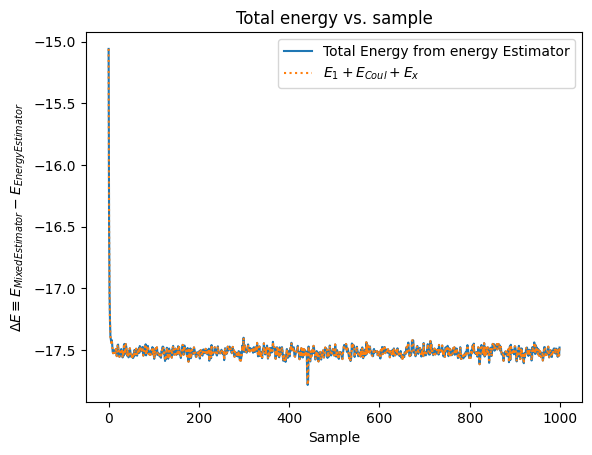

In [7]:
from types import SimpleNamespace
import matplotlib.pyplot as plt

from stats.scalar_dat import analyze_scalar_data,read_scalar_table

# read scalar table and return as a pandas DataFrame
args = SimpleNamespace(
    fname=scratch_dir / "qmc.s000.scalar.dat",
    append=None,
    mark_header="#"
)
df = read_scalar_table(args)


# read the energy components
one_body_energy = df["OneBodyEnergyEstim__nume_real"].values
direct_coulomb_energy = df["ECoulEnergyEstim__nume_real"].values
exchange_energy = df["EXXEnergyEstim__nume_real"].values

two_body_energy = direct_coulomb_energy + exchange_energy

# read the total energy
total_energy = df["EnergyEstim__nume_real"].values

# plot the energy both ways

plt.plot(total_energy,label="Total Energy from energy Estimator")
plt.plot(one_body_energy + direct_coulomb_energy + exchange_energy, ":", label=r"$E_1 + E_{Coul} + E_{x}$")

plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"Total energy vs. sample")

plt.show()

&nbsp;

## Computing Observables using a "Mixed" Estimator
---

SAFIRE also includes a mixed estimator that periodically evaluates,

$$
\langle \hat{O} ⟩_{Mixed} = \frac{1}{\sum_k W_{n,k}} \sum_k W_{n,k} \frac{\langle \Psi_T | \hat{O} | \Phi_{n,k} \rangle }{\langle \Psi_T | \Phi_{n,k} \rangle},
$$
where $\hat{O}$ is an operator.
The one-body reduced density matrix (1rdm), given by

$$\hat{O} = \hat{\rho}^1 = \sum_{ij}\sum_{\sigma \sigma'} \hat{c}^\dagger_{i \sigma}\hat{c}_{j \sigma'},$$

and the two-body reduced density matrix (2rdm), given by,

$$\hat{O} = \hat{\rho}^2 = \sum_{ijkl}\sum_{\sigma \sigma'}\hat{c}^\dagger_{i\sigma}\hat{c}^\dagger_{j\sigma'}\hat{c}_{k\sigma'}\hat{c}_{l\sigma}$$

are common observables.

<div class="alert alert-block alert-info">
<b>Note:</b>
    computing the 2rdm is very time and memory intensive; this should only be done for small systems.
</div>

It is also possible to compute the "diagonal" 2rdm which we define as,

$$
\hat{O} = \hat{\rho}^{2-diag} = \sum_{ij}\sum_{\sigma \sigma'}\hat{c}^\dagger_{i\sigma}\hat{c}^\dagger_{j\sigma'}\hat{c}_{j\sigma'}\hat{c}_{i\sigma},
$$

This requires signficantly less compute time and memory usage than the full 2-rdm and should be preferred whenever possible!

### Specifying Observables to Measure
---------------------------------------

You can specify which observables you want to compute by
adding a corresponding observable block to an estimator
block.
For example, the estimator block below includes both the 1rdm, and the diagonal 2rdm.

```json
"estimator" : {
    "name" : "mixed",
    "onerdm" : {
        "name" : "my_onerdm"
    },
    "diag2rdm" : {
        "name" : "my_diag2rdm"
    }
}
```

As we will see later, this is exactly how observables are specified for the BP estimator as well.
See the [User Manual](https://users.flatironinstitute.org/~beskridge/safire/user_manual/observables.html#observables) for a complete list of currently implemented observables.

### Pedagogical Demonstration
-----------------------------

Below, we will use a mixed estimator to compute the 1-rdm, and the diagonal 2-rdm.
We can then directly compute each contribution to the AFQMC energy,

$$E_{one-body} = \sum_{ij} \sum_{\sigma, \sigma'} H^1_{ij} \rho^1_{j\sigma', i\sigma} $$

$$E_U = U \sum_{i} \rho^{2-diag}_{i \uparrow i \downarrow}$$

and compare with the results from the energy estimator.
**We should find exact agreement between the two if we use the same AFQMC run parameters.**

Run the code below to write the input file!

In [8]:
from afqmctools.inputs.from_hdf import write_json

# some shared parameters for the AFQMC run
execute_options = {
    "walker_set" : {
        "walker_type" : "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "population_control_interval" : 10,
    "measure_interval_multiplier": 1,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 200,
    "seed" : 42,
    "estimator" : {
        "name" : "mixed",
        "onerdm" : {
            "name" : "my_onerdm"
        },
        "diag2rdm" : {
            "name" : "my_diag2rdm"
        }
    }
}

print(execute_options)

write_json(
    scratch_dir / "afqmc_1.json",
    fwfn0=scratch_dir / "uhf_wfn.h5",
    fham0=scratch_dir / "hamiltonian.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options,
    series=1
)

{'walker_set': {'walker_type': 'COLLINEAR'}, 'timestep': 0.01, 'steps': 10000, 'population_control_interval': 10, 'measure_interval_multiplier': 1, 'walker_ortho_interval': 10, 'n_walkers_per_mpi_task': 200, 'seed': 42, 'estimator': {'name': 'mixed', 'onerdm': {'name': 'my_onerdm'}, 'diag2rdm': {'name': 'my_diag2rdm'}}}


Now, we can run AFQMC with a Mixed Estimator in order to compute the 1-rdm.
**This will probably take a while!** To finish the tutorial more quickly, remove the "twordm" block from the input and just compate the one-body energy.

In [9]:
run_afqmc(
    run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there as well
    input_file="afqmc_1.json",
    np=16,                              # number of MPI tasks
    output_file=None
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin050 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: f98e57cf7913d3d513ec26d69d9fd43f9eae11df
app git commit date: Wed Mar 4 09:24:44 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 1 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: uhf_wfn.h5
walker_set: 
  walker_type: COLLINEAR
hamiltonian: 
  filename: hamiltonian.h5
hdf_read_file: 
set_nwalker_to_target: false
n_walkers_per_mpi_task: 200
timestep: 0.01
seed: 4

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:      0.02126479   1.9508982e-05     1090
      WalkerSetBase::branching:      0.33845455   0.00031050876     1090
                         Block:       412180.77       41.218077    10000
                  PseudoEnergy:       5.4670651   0.00054670651    10000
                        Energy:               0               0        0
                           vHS:       0.3219561    3.219561e-05    10000
                             X:       3.2353396   0.00032353396    10000
                         vbias:       1.5290975   0.00015290975    10000
                   G_for_vbias:       10.914339    0.0010914339    10000
                     Propagate:       19.538836    0.0019538836    10000
                MixedEstimator:       22.8951

83.22770256083459

### Data Extraction and Analysis
---

afqmctools provides several tools for extracting data - i.e. retrieving data from the SAFIRE output files - and analyzing data - ariving at a final average with stochastic uncertainty.

Since some observables require a large amount of memory to store, `afqmctools` also provides "transforms" which are applied to the raw observables as they are read from disk.
For example, in the cell below, a enery evaluation transform is used to compute the one-body energy, a scalar, on the fly as one-rdm samples are read from the *.h5 data file.
This dramatically reduces the memory needed to analyze the AFQMC results from SAFIRE.

Walker type:  collinear


/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


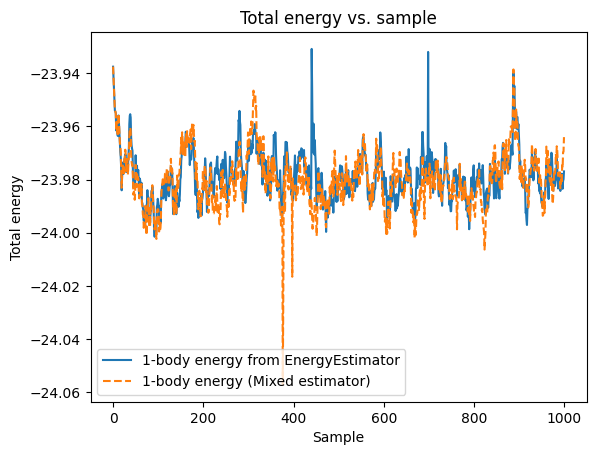

In [10]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np

from afqmctools.hamiltonian.converter import read_common_input
from afqmctools.analysis.extraction import extract_observable,get_metadata
from afqmctools.analysis.transform import hermitize_factory,eval_one_body_obs_factory,eval_two_body_obs_factory

from afqmctools.analysis.average import WALKER_TYPE


# get the one-body Hamiltonian from the Hamiltonian object
hcore = hamiltonian.get_one_body().toarray()
M = hcore.shape[1]

walker_type = WALKER_TYPE[get_metadata(scratch_dir/"qmc.s001.stat.h5")["WalkerType"]]

print("Walker type: ", walker_type)

# set up a transform to compute the one-body energy from the one-rdm
eval_one_body_energy = eval_one_body_obs_factory(
    one_body_operator=hcore,
    walker_type=walker_type
)
# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

# Extract and Transform data
Energy_1body = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",    # filename
    estimator='mixed',
    name="one_rdm",                    # observable type
    ix=0,                              # index of the "average" - we'll return to this below!
    transform=[hermitize,eval_one_body_energy],  # list of transforms to apply *FROM LEFT TO RIGHT*
)

plt.plot(one_body_energy,label="1-body energy from EnergyEstimator")
plt.plot(Energy_1body,'--',label="1-body energy (Mixed estimator)")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Total energy")
plt.title("Total energy vs. sample")
plt.show()

(1000, 1)
(1000,)


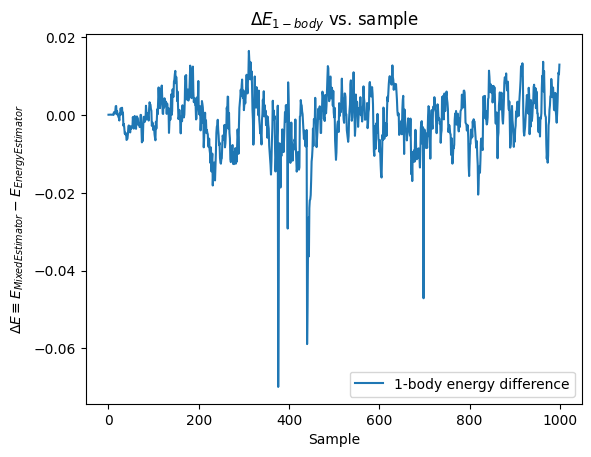

In [11]:
# now, look at the difference!
delta_E = Energy_1body[:,0] - one_body_energy

print(Energy_1body.shape)
print(one_body_energy.shape)

# plot the difference between the two energies
plt.plot(delta_E,label="1-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{1-body}$ vs. sample")

plt.show()

As we can see, the energy computed using the one-body reduced density matrix with a mixed estimator yeilds the exact same one-body energies as the energy estimator to very high precision.
This is no surprise since the energy estimator is simply a specialized mixed estimator.


### Your Turn : Extract the 2rdm and compute the 2-body energy
---

Repeat the same excercise for the two-body energy.
As we saw in the energy estimator section, the exchange and direct coulomb energies are printed to file separately by the energy estimator.

To compute the two-body energy, you will need to measure the "diag_twordm" observable during AFQMC, and extract and transform it.

We provide code for setting up the appropriate transform functions in the code block below.

Note that the diagonal 2-rdm is stored as the upper-triangular of the full matrix.

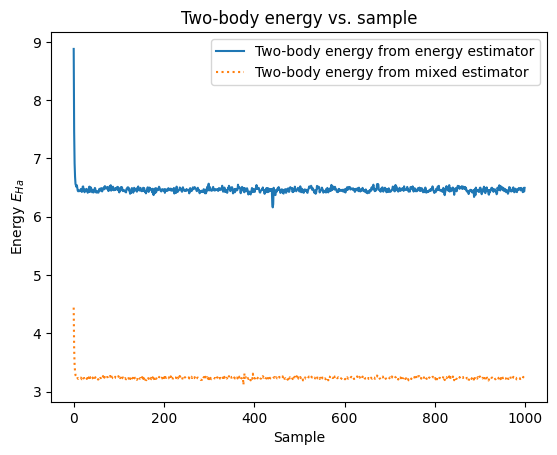

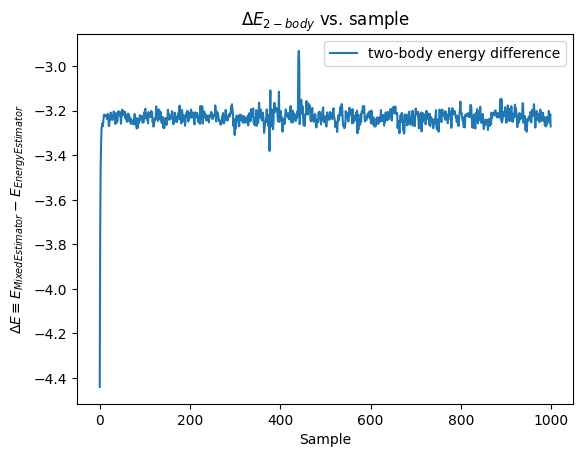

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from afqmctools.analysis.transform import eval_hubbard_from_diag_two_rdm_factory,upper_triangle_factory

U = 4.0

# setup transform to compute the Hubbard energy from diag2rdm
eval_Hubbard_U = eval_hubbard_from_diag_two_rdm_factory(
    U=U,
    walker_type=walker_type
)

# set up a transform from upper-triangular to full matrix
upper_tri_to_full = upper_triangle_factory(
    walker_type=walker_type
)

# extract and transform data
Energy_HubbardU = extract_observable(
    scratch_dir/"qmc.s001.stat.h5",
    estimator='mixed',
    name="diag_two_rdm",               # observable type
    ix=0,                              # index of the "average" - we'll return to this below!
    transform=[upper_tri_to_full,eval_Hubbard_U],  # list of transforms to apply *FROM LEFT TO RIGHT*
)


plt.plot(two_body_energy,label="Two-body energy from energy estimator")
plt.plot(Energy_HubbardU,":",label="Two-body energy from mixed estimator")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"Energy $E_{Ha}$")
plt.title("Two-body energy vs. sample")
plt.show()


# plot the difference as well!
delta_E = Energy_HubbardU[:,0] - two_body_energy

# plot the difference between the two energies
plt.plot(delta_E,label="two-body energy difference")
plt.legend()
plt.xlabel("Sample")
plt.ylabel(r"$\Delta E \equiv E_{MixedEstimator} - E_{EnergyEstimator}$")
plt.title(r"$\Delta E_{2-body}$ vs. sample")

plt.show()


Once again, we see that the two body energy computed from the two-body reduced density matrix samples is the same as the two body energy from the energy estimator (after adding the exchange and direct Coulomb contributions together, of course).

## Averaging Observables
---

Averaging observables computed using AFQMC requires some care.

First, one must make sure that the data is equilibrated.

Second, in AFQMC, successive samples are not independent since they depend on the recent history of each walker.
This is known as "autocorrelation".
Care must be take to remove autocorrelation effects or the stochastic uncertainty will be underestimated.

The former can be achieved by visualizing the observable over imaginary time, and finding the equilibration time by inspection.
We saw this in the [Hello SAFIRE](../01_hello_safire/01_hello_safire.html) tutorial.
afqmctools provides tools for automatically computing the auto-correlation time - i.e. the time interval at which measurments are no longer autocorrelated - and adjusting the number of effective samples accordingly.

In the code cell below, we demonstrate how to use the provided tools to automatically compute averages.

Average energy from average_observable() and transforms: [-20.7485318+0.j] +/- [0.00172426]


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/lweber/.scratch/08_observables_lattice/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           



AFQMC Energy   -17.518414 +/-   0.001932 3.00  5.0/100.0


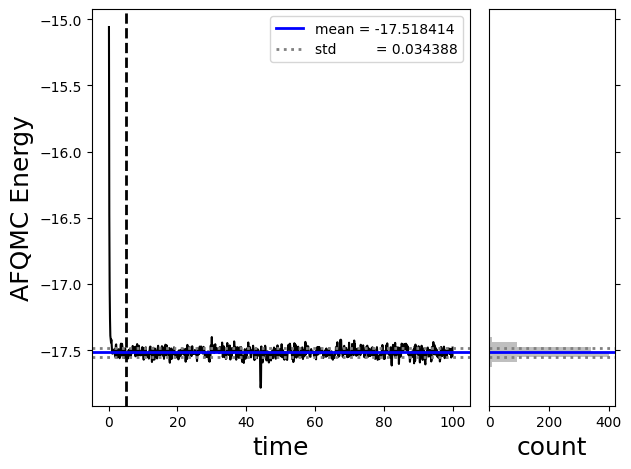

In [13]:
# TODO here: demonstrate how to automatically average observables!
from afqmctools.analysis.average import average_observable

E1body, dE1body = average_observable(
    filename=scratch_dir/"qmc.s001.stat.h5",
    name = "one_rdm",
    eqlb=20, # EXERCISE: Set this to an appropriate value based on the energy vs projection time curve above.
    estimator='mixed',
    ix=0,
    blocksize=1,
    transform=[hermitize,eval_one_body_energy],
    remove_auto_correlation=True # you can turn this off if you prefer to remove autocorrelation yourself.
)

E2body, dE2body = average_observable(
    filename=scratch_dir/"qmc.s001.stat.h5",
    name = "diag_two_rdm",
    eqlb=20, # EXERCISE: Set this to an appropriate value based on the energy vs projection time curve
    estimator='mixed',
    ix=0,
    blocksize=1,
    transform=[upper_tri_to_full,eval_Hubbard_U],
    remove_auto_correlation=True
)

print(f"Average energy from average_observable() and transforms: {E1body + E2body} +/- {np.sqrt(dE1body**2 + dE2body**2)}")

## compare with the analyze_scalar_stats result:

from stats.scalar_dat import analyze_scalar_data

_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    nequil = 5,
    trace = True
))

## Back-Propagation (BP) in SAFIRE
---

Mixed estimators are biased for observables $\hat{O}$ such that $[\hat{O},\hat{H}] \neq 0$, which requires the use of pure estimators. The Back-Propagation (BP) algorithm is used to compute pure estimators efficiently in SAFIRE.

### Basic BP Configuration
---

BP is invoked in SAFIRE by including a "back_propagation" estimator in the input file:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 5,
    "measure_interval_multiplier": 20,
    "equil_multiplier": 100,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

Observables are added to the BP block in the same way as for mixed estimators.

### Measurement Intervals
---

Since BP involves an additional projection, the measurement interval controls the number of back-propagated steps.
Just as in the execute block or a mixed estimator block, the input file includes a measurement interval "multiplier", and the actual measurement interval, $m$, is determined as:

$$m = (\text{measure\_interval\_multiplier}) \times (\text{population\_control\_interval})$$

### Multiple BP Lengths
---

SAFIRE implements the capability of running BP with multiple BP measurement lengths.
We call each measurement with a different BP length an "average".
This allows the forward projection to be reused while checking for convergence in the BP length.
To define multiple BP lengths/averages, simply provide a JSON array for measure_interval_multiplier corresponding to all of the BP lengths that you would like to use:

```json
{
  "estimator": {
    "name": "back_propagation",
    "path_restoration": true,
    "bp_walker_ortho_interval": 10,
    "measure_interval_multiplier": [60, 70, 80],
    "equil_multiplier": 80,
    "onerdm": {
      "name": "one_rdm"
    }
  }
}
```

### Equilibration Phase
---

The BP estimator implements an equilibration phase at the beginning of the AFQMC calculation where no BP is performed.
This is recommended since computing observables is expensive and since AFQMC needs to equilibrate before samples can meaningfully contribute to the average.
Similarly to the measure_interval_multiplier, the equilibration time is specified as an equilibration multiplier (`"equil_multiplier"`) and the actual equilibration time is given by:

$$\text{equil\_time} = (\text{equil\_multiplier}) \times (\text{population\_control\_interval})$$


### All Settings
----------------

<style>
td, th {
   border: none!important;
}
</style>
  
|<font size="4"><b>setting</b></font>|<font size="4"><b>default</b></font>|<font size="4"><b>description</b></font>|
|--:|:-:|:--|
| <font size="4"><b>        measure_interval_multiplier</b></font> |  <font size="4"> 1 </font> | <font size="4"> controls the number of back propagation steps which are determined as $$(\text{number of BP steps}) = (\text{measure\_interval\_multiplier}) \times (\text{population\_control\_interval})$$. Can be either a single value or multiple values. If multiple values are provided, BP will be performed with each corresponding number of BP steps and observables are accumulated and saved for each distinct BP length. </font> |
| <font size="4"><b> equil_multiplier </b></font> | <font size="4">0</font> |  <font size="4">The multiplier that determines the length of the equilibration phase. The equilibration phase length is computed as $$(equilibration\_length) = (equil\_multiplier) * (population\_control\_inveral)$$ where the population control interval is defined in the execute block. During the equilibration phase, observables are not computed. </font>|
| <font size="4"><b>        bp_walker_ortho_interval</b></font> |  <font size="4"> 1 </font> | <font size="4">  interval for performing walker orthonormalization during back-propagation (i.e. for the left-hand side Walkers) </font> |
| <font size="4"><b>        path_restoration</b></font> |  <font size="4"> false </font> | <font size="4"> If true, perform path restoration. </font> |
| <font size="4"><b>        extra_path_restoration</b></font> |  <font size="4"> false </font> | <font size="4">  If true, perform an extra path restoration. </font> |


### Demonstraiton of BP
-----------------------

For the sake of execution time, we will compute only the one-rdm using the back-propagation estimator.
We will find that the one-body energy computed using the BP one-rdm will *not* agree with the one computed using a mixed estimator.
The BP-estimated one-body energy is unbiased, and represents a better estimate of the one-body energy than that provided by the mixed estimator.

In [14]:
# Example: Setting up a BP calculation with multiple BP lengths
from afqmctools.inputs.from_hdf import write_json

# Create a scratch directory for BP calculations
scratch_dir_bp = get_scratch_dir("observables_mols_bp", home)

# Set up AFQMC parameters with back-propagation
execute_options_bp = {
    "walker_set": {
        "walker_type": "COLLINEAR"
    },
    "timestep": 0.01,
    "steps": 10000,
    "measure_interval_multiplier": 5,
    "population_control_interval": 10,
    "walker_ortho_interval": 10,
    "n_walkers_per_mpi_task": 200,
    "seed": 42,
    "estimator": {
        "name": "back_propagation",
        "path_restoration": True,
        "bp_walker_ortho_interval": 10,
        "measure_interval_multiplier": [5, 8, 10],  # Multiple BP lengths
        "equil_multiplier": 40,  # Equilibration phase
        "onerdm": {
            "name": "one_rdm"
        }
    }
}

write_json(
    scratch_dir_bp / "afqmc_bp.json",
    fwfn0=scratch_dir / "uhf_wfn.h5",
    fham0=scratch_dir / "hamiltonian.h5",
    walker_type="COLLINEAR",
    exec_opts=execute_options_bp,
    series=2
)

print("Back-propagation input file created with the following BP parameters:")
print(f"- Multiple BP lengths: {execute_options_bp['estimator']['measure_interval_multiplier']}")
print(f"- Equilibration multiplier: {execute_options_bp['estimator']['equil_multiplier']}")
print(f"- Population control interval: {execute_options_bp['population_control_interval']}")
print(f"- Actual BP lengths: {[m * execute_options_bp['population_control_interval'] for m in execute_options_bp['estimator']['measure_interval_multiplier']]}")
print(f"- Equilibration time: {execute_options_bp['estimator']['equil_multiplier'] * execute_options_bp['population_control_interval']}")

Back-propagation input file created with the following BP parameters:
- Multiple BP lengths: [5, 8, 10]
- Equilibration multiplier: 40
- Population control interval: 10
- Actual BP lengths: [50, 80, 100]
- Equilibration time: 400


In [15]:
# Run AFQMC with back-propagation
print("Running AFQMC with back-propagation estimator...")
print("This will take longer than mixed estimators due to the additional back-propagation steps.")

run_afqmc(
    run_dir=scratch_dir_bp,
    input_file="afqmc_bp.json",
    np=16,
    output_file=None
)

Running AFQMC with back-propagation estimator...
This will take longer than mixed estimators due to the additional back-propagation steps.
Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin050 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: f98e57cf7913d3d513ec26d69d9fd43f9eae11df
app git commit date: Wed Mar 4 09:24:44 2026 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 2 
    -- MPI tasks/node : 16 
    -- MPI nodes      : 1 
    -- MPI tasks      : 16 



DrvFac::executeAFQMCNewDriver input:
wavefunction: 
  filename: ../08_observables_lattice/uhf_wfn.h5
walker_set: 
  walker_type: COLLINEAR
hamiltonian: 
  filename: ../08_observables_lattice/hamiltonian.h5
hdf_read_file: 
set_nwalker_to_target: fals

***************************************************************************
                    Timer Name:     Elapsed (s)    Averaged (s)  # calls
***************************************************************************
    WalkerSetBase::loadBalance:     0.083212437   7.6341685e-05     1090
      WalkerSetBase::branching:       0.4645484   0.00042619119     1090
                         Block:       593022.02       59.302202    10000
                  PseudoEnergy:       5.3618455   0.00053618455    10000
                        Energy:               0               0        0
                           vHS:      0.32627021   3.2627021e-05    10000
                             X:       3.1366177   0.00031366177    10000
                         vbias:       1.4833164   0.00014833164    10000
                   G_for_vbias:       10.955452    0.0010955452    10000
                     Propagate:       19.172335    0.0019172335    10000
                MixedEstimator:              

121.90286264847964

In [16]:
# Extract and analyze BP results
from afqmctools.analysis.extraction import extract_observable, get_metadata
from afqmctools.analysis.average import WALKER_TYPE
from afqmctools.analysis.transform import hermitize_factory

# Check the metadata to understand the walker type
walker_type = WALKER_TYPE[get_metadata(scratch_dir_bp / "qmc.s002.stat.h5")["WalkerType"]]
print(f"Walker type: {walker_type}")

# set up a transform the hermitize the one-rdm
hermitize = hermitize_factory(
    walker_type=walker_type
)

# Extract one-RDM data from all BP averages
print("\nExtracting one-RDM data from back-propagation averages...")

# We specified 3 BP lengths: [5, 8, 10] * population_control_interval
bp_lengths = [50, 80, 100]
bp_onerdm_data = {}

for iav, bp_length in enumerate(bp_lengths):
    print(f"Extracting average {iav} (BP length = {bp_length} * {execute_options_bp['population_control_interval']} = {bp_length * execute_options_bp['population_control_interval']} steps)")

    # Extract the one-RDM for this average
    onerdm_bp = extract_observable(
        scratch_dir_bp / "qmc.s002.stat.h5",
        estimator='back_propagated',
        name="one_rdm",
        ix=iav,  # Index of the BP average
        transform=[hermitize],  # Apply hermitization
        batch_size=10
    )
    bp_onerdm_data[iav] = onerdm_bp

print(f"\nSuccessfully extracted one-RDM data from {len(bp_onerdm_data)} BP averages")

Walker type: collinear

Extracting one-RDM data from back-propagation averages...
Extracting average 0 (BP length = 50 * 10 = 500 steps)
Extracting average 1 (BP length = 80 * 10 = 800 steps)


Extracting average 2 (BP length = 100 * 10 = 1000 steps)

Successfully extracted one-RDM data from 3 BP averages


/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/mnt/home/lweber/venvs/safire/lib/python3.11/site-packages/numpy/ma/core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


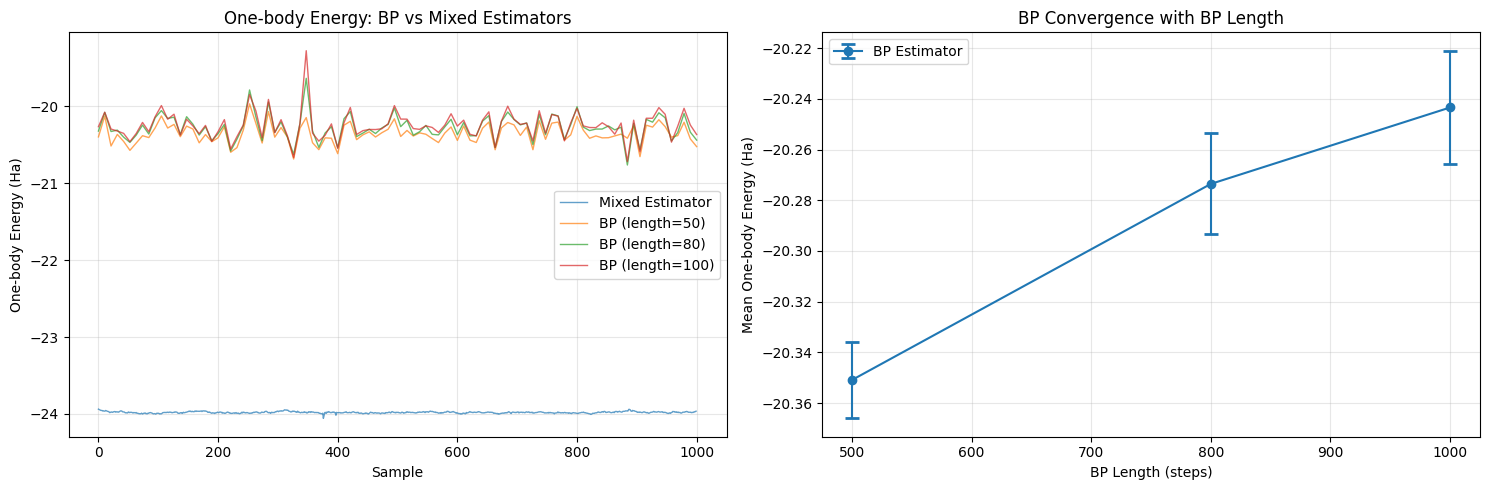


Summary of Results:
Mixed Estimator:      -23.980582+0.000000j ± 0.000317 Ha
BP (length=500):    -20.350941+0.000000j ± 0.015109 Ha
BP (length=800):    -20.273558+0.000000j ± 0.019914 Ha
BP (length=1000):    -20.243396+0.000000j ± 0.022397 Ha

Difference between longest BP and mixed estimator: 3.74e+00 t


In [17]:
# Compare BP vs Mixed Estimator and show convergence with BP length
import matplotlib.pyplot as plt
import numpy as np

# Extract mixed estimator one-RDM for comparison (from previous calculation)
onerdm_mixed = extract_observable(
    scratch_dir / "qmc.s001.stat.h5",
    estimator='mixed',
    name="one_rdm",
    ix=0,
    transform=[hermitize],
    batch_size=1
)

pop_control =  execute_options['population_control_interval']
measure_interval_multiplier = execute_options['measure_interval_multiplier']
tau = execute_options['timestep']
nsamples = onerdm_mixed.shape[0]
beta = tau * nsamples * measure_interval_multiplier * pop_control

measure_time = pop_control*measure_interval_multiplier*tau
# Compute one-body energies for all BP averages
bp_energies = {}
for iav, bp_length in enumerate(bp_lengths):
    energy_1body_bp = eval_one_body_energy(bp_onerdm_data[iav])
    bp_energies[iav] = energy_1body_bp

# Compute mixed estimator one-body energy
energy_1body_mixed = eval_one_body_energy(onerdm_mixed)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Energy traces for different BP lengths vs mixed
nsamples_bp = bp_onerdm_data[iav].shape[0]
bp_measure_time = tau * pop_control * bp_lengths[-1]
beta_bp = bp_measure_time*np.linspace(0,beta,nsamples_bp)

ax1.plot(energy_1body_mixed, label='Mixed Estimator', alpha=0.7, linewidth=1)
for iav, bp_length in enumerate(bp_lengths):
    ax1.plot(beta_bp, bp_energies[iav], label=f'BP (length={bp_length})', alpha=0.7, linewidth=1)

ax1.set_xlabel('Sample')
ax1.set_ylabel('One-body Energy (Ha)')
ax1.set_title('One-body Energy: BP vs Mixed Estimators')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Convergence of BP with respect to BP length
# Calculate mean and std for each method after equilibration (skip first 20% of samples
skip_samples = len(bp_energies[2]) // 5
means = []
stds = []
bp_length_values = []

# Mixed estimator
mixed_mean = np.mean(energy_1body_mixed[skip_samples:])
mixed_std = np.std(energy_1body_mixed[skip_samples:]) / np.sqrt(len(energy_1body_mixed[skip_samples:]))

for iav, bp_length in enumerate(bp_lengths):
    bp_mean = np.mean(bp_energies[iav][skip_samples:])
    bp_std = np.std(bp_energies[iav][skip_samples:]) / np.sqrt(len(bp_energies[iav][skip_samples:]))
    means.append(bp_mean)
    stds.append(bp_std)
    bp_length_values.append(bp_length * execute_options_bp['population_control_interval'])

# Plot convergence
ax2.errorbar(bp_length_values, means, yerr=stds, marker='o', capsize=5, capthick=2, label='BP Estimator')

ax2.set_xlabel('BP Length (steps)')
ax2.set_ylabel('Mean One-body Energy (Ha)')
ax2.set_title('BP Convergence with BP Length')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nSummary of Results:")
print(f"Mixed Estimator:      {mixed_mean:.6f} ± {mixed_std:.6f} Ha")
for iav, bp_length in enumerate(bp_lengths):
    bp_mean = means[iav]
    bp_std = stds[iav]
    actual_length = bp_length_values[iav]
    print(f"BP (length={actual_length:3d}):    {bp_mean:.6f} ± {bp_std:.6f} Ha")

print(f"\nDifference between longest BP and mixed estimator: {abs(means[-1] - mixed_mean):.2e} t")

### Key Takeaways from Back-Propagation Analysis
---

**When to Use BP vs Mixed Estimators:**

1. **Mixed Estimators**: Use for observables that commute with the Hamiltonian (like energy). They are computationally cheaper and provide unbiased estimates.

2. **Back-Propagation**: Required for observables that do not commute with the Hamiltonian (like the one-body reduced density matrix). BP provides pure estimators that are unbiased.

**Important BP Configuration Points:**

- **Equilibration**: Always include an equilibration phase (`equil_multiplier`) to allow AFQMC to reach equilibrium before BP measurements begin.

- **Multiple BP Lengths**: Use multiple BP lengths to check convergence. Longer BP lengths generally provide more accurate results up to a point. BP is unstalbe for excessively large BP length. This manifests as a sharp increase in stochastic uncertainty.

- **Computational Cost**: BP calculations are significantly more expensive than mixed estimators due to the additional back-propagation steps.

&nbsp;


&nbsp;

## Summary
---

<font size="4">
In this tutorial, you were acquainted with how to compute general observables with SAFIRE.
</font>

&nbsp;

## What you learned
---

<font size="4">

1. What a mixed estimator is and when to use one to compute an observable
2. What a back-propagated estimator is and when to use one to compute an observable
3. How to compute observables in post-processing with afqmctools
</font>

&nbsp;